# Meeting Notes: 3/11/2026
- Write explanations of your code
    - Use textcells and add section/subsection names
- Your project is using ML algorithms
    - Use more ML algorithms
        - Decision Tree
        - XGBoost
        - RNN
        - LSTM
    - Use more hyperparameter of ML algorithms
- Use my book for ML algorithms: https://datasmp.github.io/intro_ml/intro_ml.html


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

STOCK_DICT = {'Apple': 'AAPL', 'Tesla': 'TSLA', 'Amazon': 'AMZN', 'Visa': 'V', 'Microsoft': 'MSFT'}
START = '2017-1-1'
END = '2019-12-31'

df = pd.DataFrame()
for name, symbol in STOCK_DICT.items():
    df[name] = yf.Ticker(symbol).history(start=START, end=END).Close

df.dropna(inplace=True)
df.head()

,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-03 00:00:00-05:00,26.745853,14.466000,37.683498,74.530464,56.171112
2017-01-04 00:00:00-05:00,26.715921,15.132667,37.859001,75.139816,55.919773
2017-01-05 00:00:00-05:00,26.851780,15.116667,39.022499,76.021065,55.919773
2017-01-06 00:00:00-05:00,27.151136,15.267333,39.799500,77.071068,56.404488
2017-01-09 00:00:00-05:00,27.399826,15.418667,39.846001,76.639816,56.224964


In [50]:
# Data cleaning : I will remove time from the index. 
df.reset_index(inplace=True) # Date becomes a column
df['Date'] = df.Date.dt.date # Apply dt.date to Date column
df.set_index('Date', inplace=True)
df.head()


,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-03,26.745853,14.466000,37.683498,74.530464,56.171112
2017-01-04,26.715921,15.132667,37.859001,75.139816,55.919773
2017-01-05,26.851780,15.116667,39.022499,76.021065,55.919773
2017-01-06,27.151136,15.267333,39.799500,77.071068,56.404488
2017-01-09,27.399826,15.418667,39.846001,76.639816,56.224964


In [51]:
# log return = log(today) - log(yesterday) = log(today/yesterday)
df_logreturn = np.log(df/df.shift(1))
df_logreturn.dropna(inplace=True)
df_logreturn.head()

,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-04,-0.001120,0.045055,0.004646,0.008143,-0.004485
2017-01-05,0.005072,-0.001058,0.030270,0.011660,0.000000
2017-01-06,0.011087,0.009918,0.019716,0.013717,0.008631
2017-01-09,0.009118,0.009863,0.001168,-0.005611,-0.003188
2017-01-10,0.001008,-0.006115,-0.001281,-0.005397,-0.000319


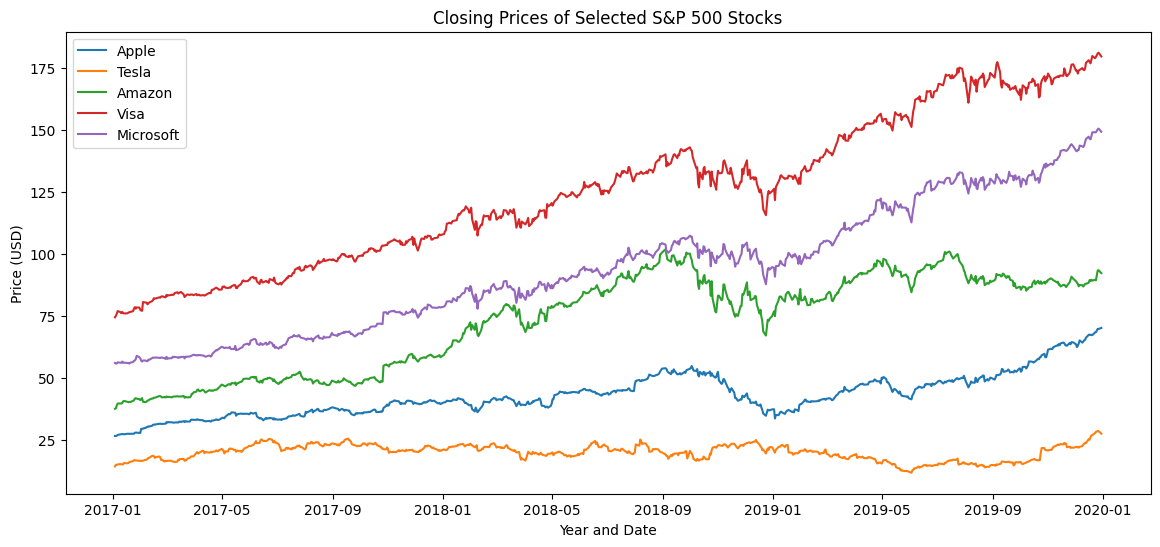

In [52]:
plt.figure(figsize=(14,6))
for col in df.columns:
    plt.plot(df[col], label=col)

plt.title("Closing Prices of Selected S&P 500 Stocks")
plt.xlabel("Year and Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Custom S&P-like data for my 5 stocks
data = {
    'Symbol': ['AAPL','TSLA','AMZN','V','MSFT','XOM','JNJ','NEE'],
    'Company': ['Apple','Tesla','Amazon','Visa','Microsoft','ExxonMobil','Johnson & Johnson','NextEra Energy'],
    'Sector': ['Technology','Consumer Cyclical','Consumer Cyclical','Financial Services',
               'Technology','Energy','Healthcare','Utilities'],
    'Marketcap': [3e12,0.8e12,1.5e12,0.5e12,3.2e12,0.45e12,0.38e12,0.17e12]
}

df_sector = pd.DataFrame(data)
df_sector

,Symbol,Company,Sector,Marketcap
0,AAPL,Apple,Technology,3.000000e+12
1,TSLA,Tesla,Consumer Cyclical,8.000000e+11
2,AMZN,Amazon,Consumer Cyclical,1.500000e+12
3,V,Visa,Financial Services,5.000000e+11
4,MSFT,Microsoft,Technology,3.200000e+12
5,XOM,ExxonMobil,Energy,4.500000e+11
6,JNJ,Johnson & Johnson,Healthcare,3.800000e+11
7,NEE,NextEra Energy,Utilities,1.700000e+11


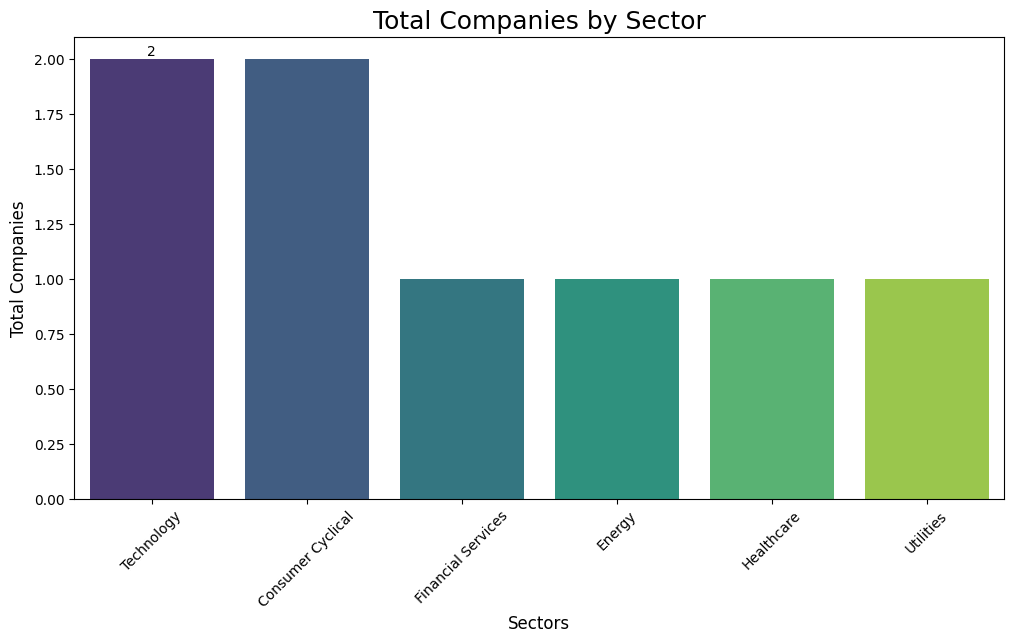

In [54]:
plt.figure(figsize=(12,6))
sec_count = sns.countplot(
    x='Sector',
    data=df_sector,
    order=df_sector['Sector'].value_counts().index,
    palette='viridis'
)

sec_count.bar_label(sec_count.containers[0], label_type='edge')
plt.xticks(rotation=45)
plt.xlabel('Sectors', size=12)
plt.ylabel('Total Companies', size=12)
plt.title('Total Companies by Sector', size=18)
plt.show()

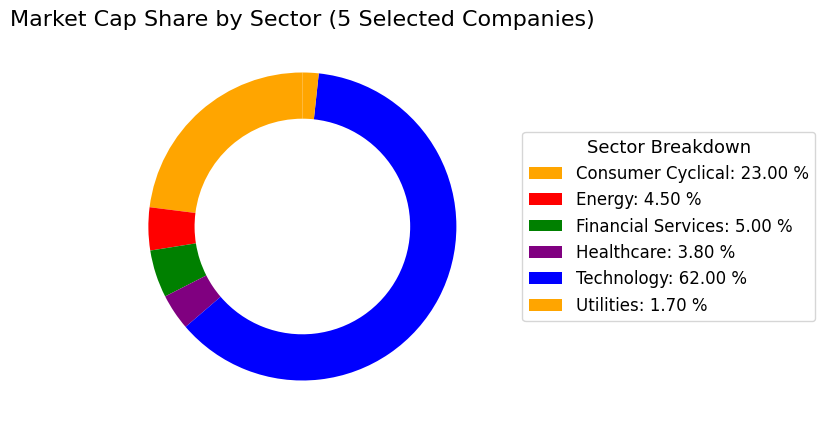

In [55]:
plt.figure(figsize=(5,5))

# Color mapping for 5 sectors
colors = ['orange', 'red', 'green', 'purple', 'blue']

secm = df_sector.groupby('Sector')['Marketcap'].sum().reset_index()
percent = 100 * (secm['Marketcap'] / secm['Marketcap'].sum())

patches, _ = plt.pie(
    secm['Marketcap'],
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.3) # To make it a donut chart if desired, or remove this line
)

# Create custom labels for the legend box
labels = [
    f"{sector}: {p:.2f} %"
    for sector, p in zip(secm['Sector'], percent)
]

#This is the box you want (just like Kaggle)
plt.legend(
    patches,
    labels,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),     # move box to the right
    fontsize=12,
    title="Sector Breakdown",        # Optional title
    title_fontsize=13,
    frameon=True                     # draws the box frame
)

plt.title('Market Cap Share by Sector (5 Selected Companies)', fontsize=16)
plt.show()

In [56]:
# Reuse already-downloaded prices from Cell 2 to avoid duplicate network calls
df.head()

,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-03,26.745853,14.466000,37.683498,74.530464,56.171112
2017-01-04,26.715921,15.132667,37.859001,75.139816,55.919773
2017-01-05,26.851780,15.116667,39.022499,76.021065,55.919773
2017-01-06,27.151136,15.267333,39.799500,77.071068,56.404488
2017-01-09,27.399826,15.418667,39.846001,76.639816,56.224964


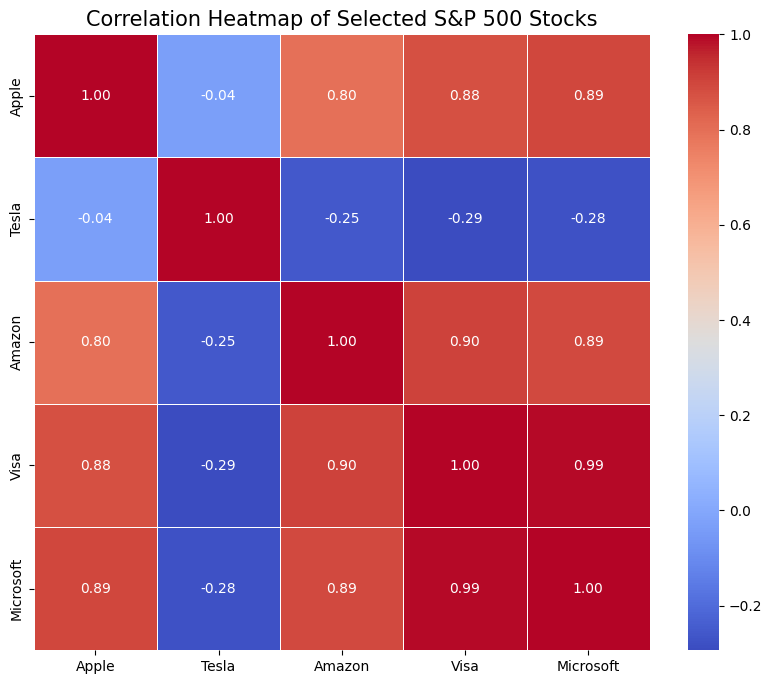

In [57]:
# Correlation of your 5 stocks
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Selected S&P 500 Stocks", fontsize=15)
plt.show()

In [58]:
# Build the ML dataset

# choose the stock you want to predict
target_stock = 'Apple'      # change to 'Tesla', 'Amazon', etc. if you want

# Make a copy with just that column
ml_df = df[[target_stock]].copy()
ml_df.rename(columns={target_stock: 'Price'}, inplace=True)

# Create target = tomorrow's price
ml_df['Target'] = ml_df['Price'].shift(-1)

# Feature engineering: past 5 daily returns
ml_df['Return_1'] = ml_df['Price'].pct_change(1)
ml_df['Return_2'] = ml_df['Price'].pct_change(2)
ml_df['Return_3'] = ml_df['Price'].pct_change(3)
ml_df['Return_4'] = ml_df['Price'].pct_change(4)
ml_df['Return_5'] = ml_df['Price'].pct_change(5)

# Drop rows with NaN created by shift / pct_change
ml_df.dropna(inplace=True)

ml_df.head()

,Price,Target,Return_1,Return_2,Return_3,Return_4,Return_5
Date,,,,,,,
2017-01-10,27.427456,27.574831,0.001008,0.010177,0.021439,0.026633,0.025484
2017-01-11,27.574831,27.459698,0.005373,0.006387,0.015605,0.026927,0.032150
2017-01-12,27.459698,27.411337,-0.004175,0.001176,0.002185,0.011365,0.022640
2017-01-13,27.411337,27.632397,-0.001761,-0.005929,-0.000588,0.000420,0.009583
2017-01-17,27.632397,27.630095,0.008065,0.006289,0.002088,0.007472,0.008488


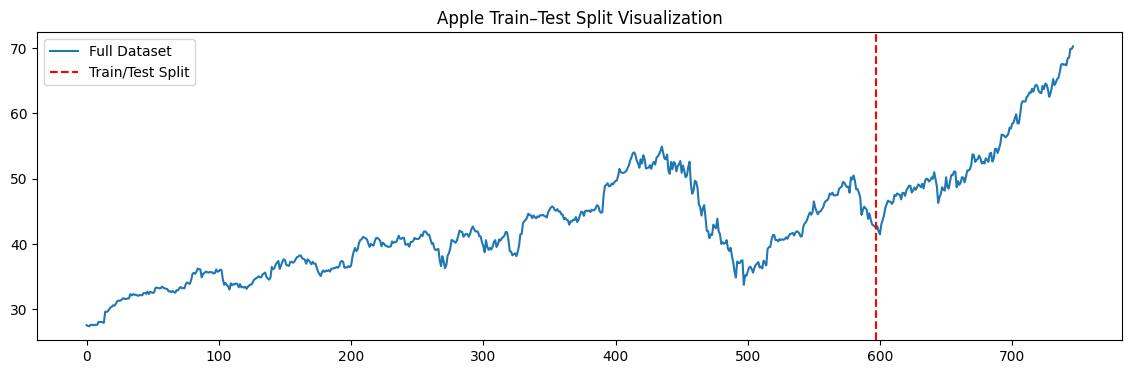

In [59]:
from sklearn.model_selection import train_test_split

X = ml_df[["Price","Return_1","Return_2","Return_3","Return_4","Return_5"]]
y = ml_df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

plt.figure(figsize=(14,4))
plt.plot(y.values, label="Full Dataset")
plt.axvline(len(y_train), color='red', linestyle='--', label="Train/Test Split")
plt.title(f"{target_stock} Train–Test Split Visualization")
plt.legend()
plt.show()

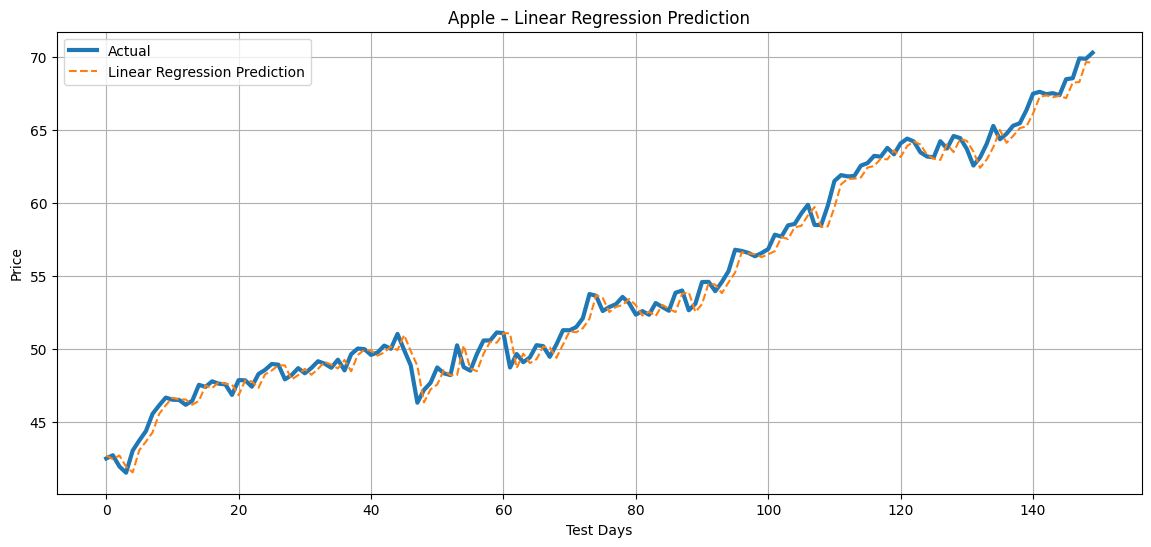

In [60]:
# Linear Regressiin model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(lr_pred, label="Linear Regression Prediction", linestyle="--")
plt.title(f"{target_stock} – Linear Regression Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

Random Forest MAE: 3.9702959291670057
Random Forest R^2: 0.27690949708931656


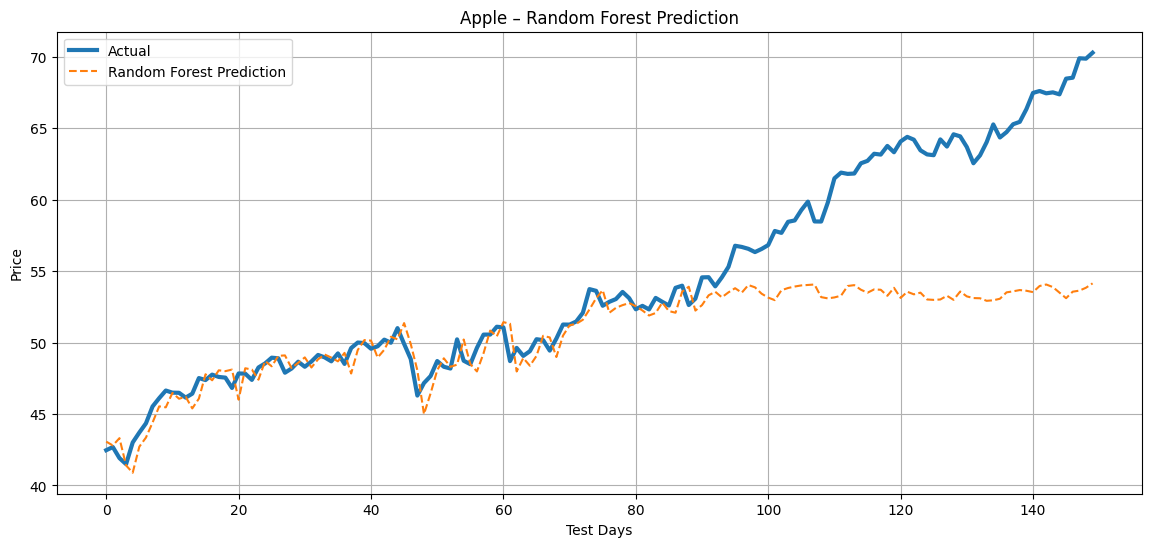

In [61]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=120,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R^2:", rf_r2)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(rf_pred, label="Random Forest Prediction", linestyle="--")
plt.title(f"{target_stock} – Random Forest Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

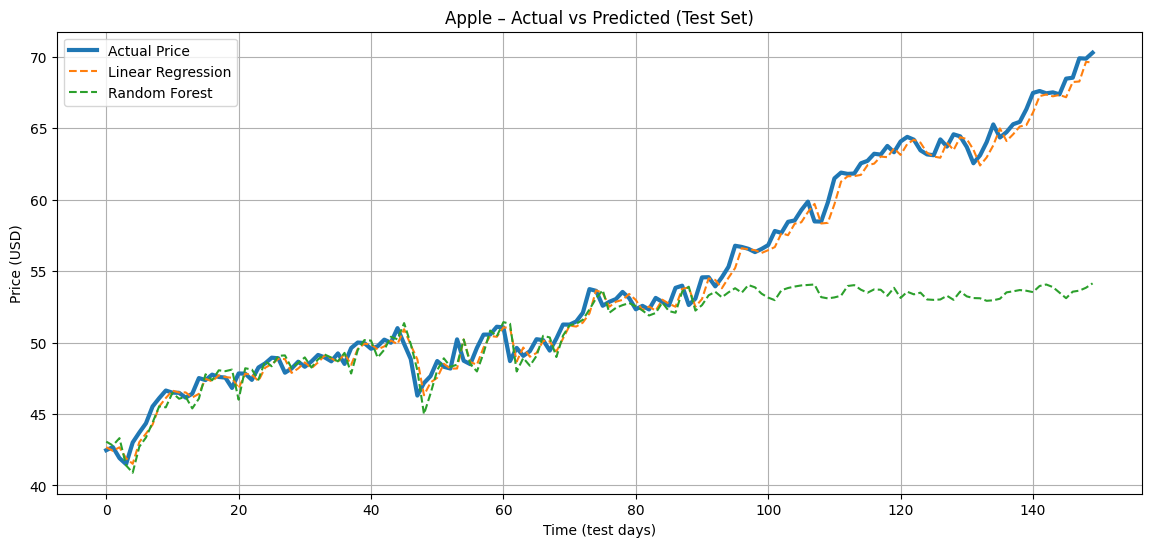

In [62]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual Price', linewidth=3)
plt.plot(lr_pred, label='Linear Regression', linestyle='--')
plt.plot(rf_pred, label='Random Forest', linestyle='--')

plt.title(f"{target_stock} – Actual vs Predicted (Test Set)")
plt.xlabel("Time (test days)")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})
results

,Model,MAE,R2 Score
0,Linear Regression,0.614452,0.988167
1,Random Forest,3.970296,0.276909


## Decision Tree Model

In this section, I use a Decision Tree Regressor to predict the next-day stock price based on the current price and the past 5 daily returns. A decision tree works by splitting the data into smaller groups based on feature values and making predictions from those splits. This model is useful because it can capture nonlinear relationships in stock price movements. I will train the model on the training dataset and then evaluate its performance using Mean Absolute Error (MAE) and R² Score.


Decision Tree MAE: 4.099561240248366
Decision Tree MSE: 40.509652862106066
Decision Tree R^2: 0.23957213059916715


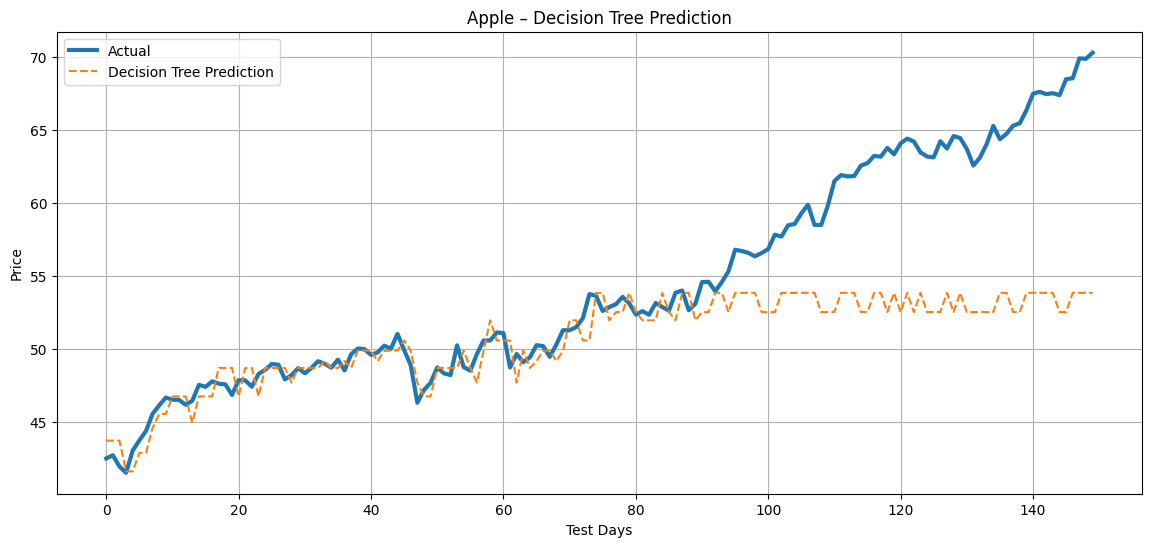

In [64]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt = DecisionTreeRegressor(
    criterion="squared_error",   # this is the MSE-based split rule
    max_depth=5,                 # tune this
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2  = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree R^2:", dt_r2)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(dt_pred, label="Decision Tree Prediction", linestyle="--")
plt.title(f"{target_stock} – Decision Tree Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [65]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest","Decision Tree"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        dt_mae
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        dt_r2
    ]
})
results

,Model,MAE,R2 Score
0,Linear Regression,0.614452,0.988167
1,Random Forest,3.970296,0.276909
2,Decision Tree,4.099561,0.239572


In [66]:
# In this section, I will add XGBoost.